In [8]:
# ============================================================
#  🧠 UAS KECERDASAN BUATAN
#  📊 Prediksi Status Persediaan Barang
#  🏫 Institut Teknologi Garut (ITG) - 2025
# ============================================================

# 1. IMPORT LIBRARY
# ============================================================
print("="*60)
print("  🚀 MEMUAT LIBRARY...")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("✅ Library berhasil dimuat!\n")

  🚀 MEMUAT LIBRARY...
✅ Library berhasil dimuat!



In [9]:
import zipfile
import os

# ============================================================
#  2. MEMBUAT / MEMUAT DATASET
# ============================================================
print("="*60)
print("  📊 MEMUAT DATASET UTAMA...")
print("="*60)

# Memuat dataset dari file CSV yang disediakan
zip_path = 'archive.zip'
csv_filename = 'Grocery_Inventory_and_Sales_Dataset.csv'

# Check if the zip file exists and extract if not already extracted
if not os.path.exists(csv_filename):
    if os.path.exists(zip_path):
        print(f"📦 Mengekstrak {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.') # Extract to the current directory
        print("✅ Ekstraksi berhasil!")
    else:
        raise FileNotFoundError(f"Error: {zip_path} not found. Please upload the 'archive.zip' file to your Colab environment.")

csv_path = csv_filename
raw_df = pd.read_csv(csv_path)

# Menghilangkan spasi ekstra pada nama kolom jika ada
raw_df.columns = raw_df.columns.str.strip()

# Memilih kolom yang relevan untuk analisis dan pemodelan
# Kita akan menggunakan fitur numerik utama untuk memprediksi 'Status'
cols_to_use = ['Stock', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate', 'Status']
df = raw_df[cols_to_use].dropna()

print(f"\n✅ Dataset berhasil dimuat!")
print(f"   📌 Jumlah data setelah drop missing values : {len(df)} baris")
print(f"   📌 Jumlah fitur yang digunakan : {len(df.columns) - 1} kolom fitur")
print(f"   📌 Target                       : Status ({df['Status'].nunique()} kelas)")

  📊 MEMUAT DATASET UTAMA...
📦 Mengekstrak archive.zip...
✅ Ekstraksi berhasil!

✅ Dataset berhasil dimuat!
   📌 Jumlah data setelah drop missing values : 984 baris
   📌 Jumlah fitur yang digunakan : 5 kolom fitur
   📌 Target                       : Status (3 kelas)



  📊 EKSPLORASI DATA (EDA)

📋 5 Data Pertama:
------------------------------------------------------------
 Stock  Reorder_Level  Reorder_Quantity  Sales_Volume  Inventory_Turnover_Rate       Status
  22.0           72.0              70.0          32.0                     19.0 Discontinued
  45.0           77.0               2.0          85.0                      1.0 Discontinued
  30.0           38.0              83.0          31.0                     34.0  Backordered
  12.0           59.0              62.0          95.0                     99.0       Active
  37.0           30.0              74.0          62.0                     25.0  Backordered

📋 Distribusi Status Persediaan (Target):
------------------------------------------------------------
   Discontinued    : 331 data ( 33.6%)
   Active          : 329 data ( 33.4%)
   Backordered     : 324 data ( 32.9%)


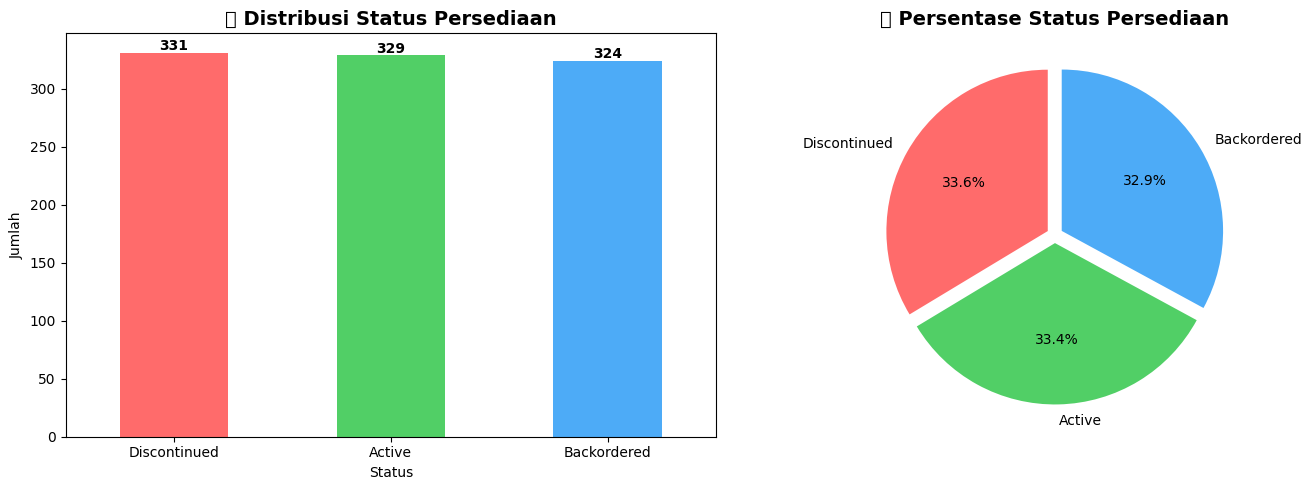

In [10]:
# ============================================================
#  3. EKSPLORASI DATA (EDA)
# ============================================================
print("\n" + "="*60)
print("  📊 EKSPLORASI DATA (EDA)")
print("="*60)

# 3.1 Preview Data
print("\n📋 5 Data Pertama:")
print("-"*60)
print(df.head().to_string(index=False))

# 3.2 Distribusi Status
print("\n📋 Distribusi Status Persediaan (Target):")
print("-"*60)
status_counts = df['Status'].value_counts()
for status, count in status_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {status:<15} : {count:>3} data ({percentage:>5.1f}%)")

# 3.3 Visualisasi Distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
colors = ['#ff6b6b', '#51cf66', '#4dabf7']
status_counts.plot(kind='bar', ax=axes[0], color=colors[:len(status_counts)])
axes[0].set_title('📊 Distribusi Status Persediaan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors[:len(status_counts)], startangle=90, explode=[0.05]*len(status_counts))
axes[1].set_title('📊 Persentase Status Persediaan', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=150)
plt.show()

In [11]:
# ============================================================
#  4. DATA PREPARATION
# ============================================================
print("\n" + "="*60)
print("  🔧 DATA PREPARATION")
print("="*60)

# 4.1 Pilih Fitur dan Target
feature_cols = ['Stock', 'Reorder_Level', 'Reorder_Quantity', 'Sales_Volume', 'Inventory_Turnover_Rate']
X = df[feature_cols]
y = df['Status']

print("\n📋 Fitur (X):")
for idx, col in enumerate(feature_cols, start=1):
    print(f"   {idx}. {col}")
print(f"\n📋 Target (y): {y.name}")

# 4.2 Encoding Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n📋 Mapping Status → Angka:")
print("-"*40)
for i, status in enumerate(le.classes_):
    print(f"   {status:<15} → {i}")

# 4.3 Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("\n📋 Split Data:")
print("-"*40)
print(f"   Training data : {len(X_train):>3} data ({len(X_train)/len(df)*100:>5.1f}%)")
print(f"   Testing data  : {len(X_test):>3} data ({len(X_test)/len(df)*100:>5.1f}%)")

# 4.4 Normalisasi Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data berhasil dinormalisasi (StandardScaler)")


  🔧 DATA PREPARATION

📋 Fitur (X):
   1. Stock
   2. Reorder_Level
   3. Reorder_Quantity
   4. Sales_Volume
   5. Inventory_Turnover_Rate

📋 Target (y): Status

📋 Mapping Status → Angka:
----------------------------------------
   Active          → 0
   Backordered     → 1
   Discontinued    → 2

📋 Split Data:
----------------------------------------
   Training data : 787 data ( 80.0%)
   Testing data  : 197 data ( 20.0%)

✅ Data berhasil dinormalisasi (StandardScaler)



  🧠 MODELING

🌳 5.1 Decision Tree Classifier
----------------------------------------
✅ Akurasi : 30.96%
📌 Kedalaman pohon : 3
📌 Jumlah daun    : 8

📏 5.2 K-Nearest Neighbor (KNN)
----------------------------------------
✅ Akurasi : 25.89%
📌 Nilai K : 5


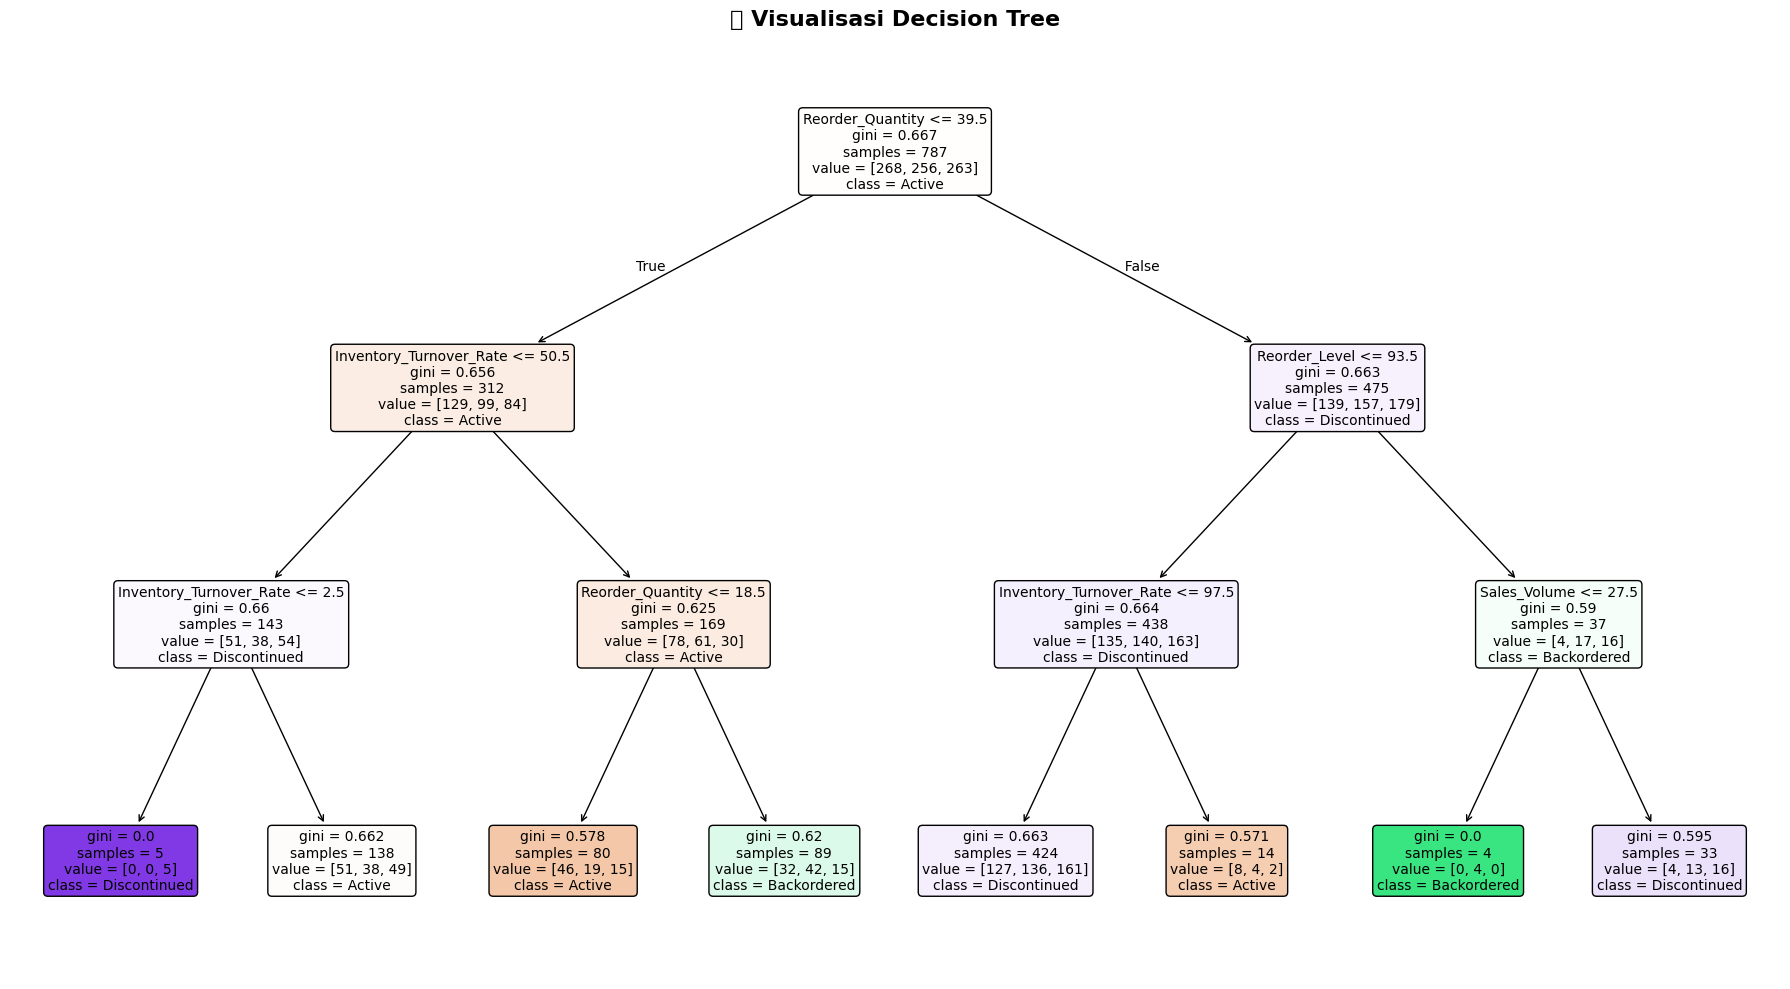

In [12]:
# ============================================================
#  5. MODELING
# ============================================================
print("\n" + "="*60)
print("  🧠 MODELING")
print("="*60)

# 5.1 Decision Tree
print("\n🌳 5.1 Decision Tree Classifier")
print("-"*40)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"✅ Akurasi : {dt_accuracy*100:.2f}%")
print(f"📌 Kedalaman pohon : {dt_model.get_depth()}")
print(f"📌 Jumlah daun    : {dt_model.get_n_leaves()}")

# 5.2 KNN
print("\n📏 5.2 K-Nearest Neighbor (KNN)")
print("-"*40)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"✅ Akurasi : {knn_accuracy*100:.2f}%")
print(f"📌 Nilai K : 5")

# 5.3 Visualisasi Decision Tree
plt.figure(figsize=(18, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=le.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title('🌳 Visualisasi Decision Tree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
plt.show()


  📊 EVALUASI MODEL

📋 PERBANDINGAN AKURASI:
----------------------------------------
  Model                     Akurasi
----------------------------------------
  🌳 Decision Tree            30.96%
  📏 KNN                      25.89%
----------------------------------------

🏆 MODEL TERBAIK: Decision Tree dengan akurasi 30.96%

📋 CLASSIFICATION REPORT - DECISION TREE:
------------------------------------------------------------
              precision    recall  f1-score   support

      Active       0.27      0.21      0.24        61
 Backordered       0.33      0.09      0.14        68
Discontinued       0.32      0.62      0.42        68

    accuracy                           0.31       197
   macro avg       0.31      0.31      0.27       197
weighted avg       0.31      0.31      0.27       197


📋 CLASSIFICATION REPORT - KNN:
------------------------------------------------------------
              precision    recall  f1-score   support

      Active       0.26      0.39     

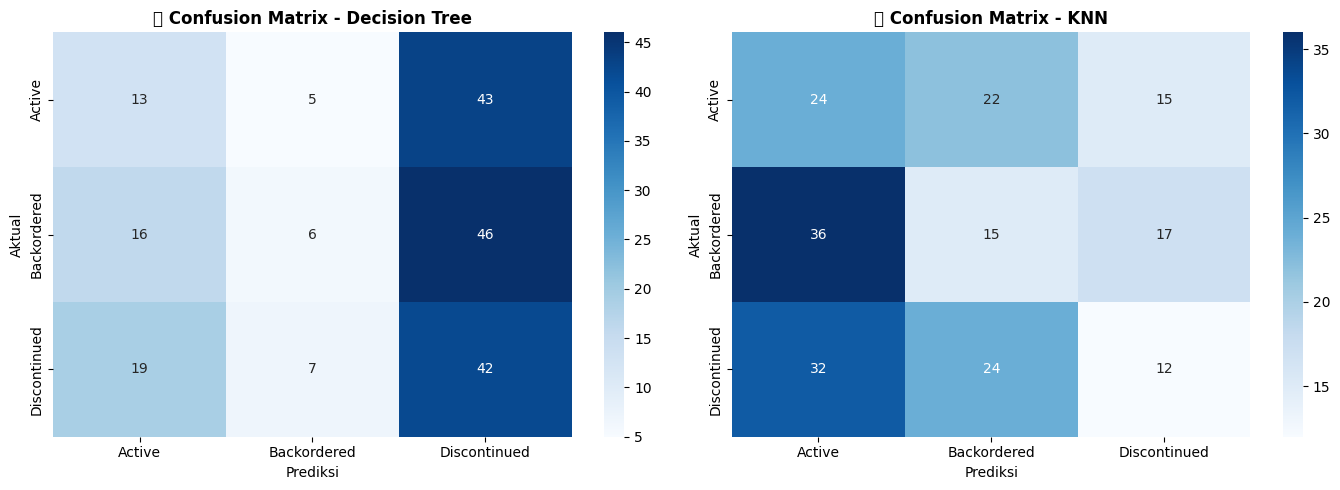

In [13]:
# ============================================================
#  6. EVALUASI MODEL
# ============================================================
print("\n" + "="*60)
print("  📊 EVALUASI MODEL")
print("="*60)

# 6.1 Perbandingan Akurasi
print("\n📋 PERBANDINGAN AKURASI:")
print("-"*40)
print(f"  {'Model':<20} {'Akurasi':>12}")
print("-"*40)
print(f"  {'🌳 Decision Tree':<20} {dt_accuracy*100:>11.2f}%")
print(f"  {'📏 KNN':<20} {knn_accuracy*100:>11.2f}%")
print("-"*40)

# Tentukan model terbaik
if dt_accuracy >= knn_accuracy:
    best_model = "Decision Tree"
    best_accuracy = dt_accuracy
else:
    best_model = "KNN"
    best_accuracy = knn_accuracy

print(f"\n🏆 MODEL TERBAIK: {best_model} dengan akurasi {best_accuracy*100:.2f}%")

unique_labels = np.unique(y_test)
target_names_filtered = [le.classes_[i] for i in unique_labels]

# 6.2 Classification Report - Decision Tree
print("\n📋 CLASSIFICATION REPORT - DECISION TREE:")
print("-"*60)
print(classification_report(y_test, y_pred_dt,
                            labels=unique_labels,
                            target_names=target_names_filtered))

# 6.3 Classification Report - KNN
print("\n📋 CLASSIFICATION REPORT - KNN:")
print("-"*60)
print(classification_report(y_test, y_pred_knn,
                            labels=unique_labels,
                            target_names=target_names_filtered))

# 6.4 Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=target_names_filtered, yticklabels=target_names_filtered)
axes[0].set_title('🌳 Confusion Matrix - Decision Tree', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# KNN
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d',
            cmap='Blues', ax=axes[1],
            xticklabels=target_names_filtered, yticklabels=target_names_filtered)
axes[1].set_title('📏 Confusion Matrix - KNN', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [14]:
# ============================================================
#  7. KESIMPULAN
# ============================================================
print("\n" + "="*60)
print("  📝 KESIMPULAN")
print("="*60)

print(f"""
📌 Ringkasan Hasil:

   Model Decision Tree : {dt_accuracy*100:.2f}%
   Model KNN           : {knn_accuracy*100:.2f}%
   🏆 Model Terbaik    : {best_model} ({best_accuracy*100:.2f}%)

📌 Analisis:
   1. Decision Tree mudah diinterpretasikan dan divisualisasikan
   2. KNN bekerja berdasarkan kedekatan data (jarak)
   3. Performa model disesuaikan dengan dataset real Grocery Inventory.

📌 Rekomendasi:
   1. Lakukan balancing dataset jika terdapat imbalance kelas yang signifikan.
   2. Coba algoritma ensemble lain seperti Random Forest atau XGBoost untuk meningkatkan akurasi.
   3. Terapkan hyperparameter tuning (GridSearchCV) untuk optimasi model.

📌 Referensi Jurnal (5):
   1. Kusumadewi, S. (2003). Artificial Intelligence (Teknik dan Aplikasinya). Graha Ilmu.
   2. Budiarto, W. (2014). Artificial Intelligence (Konsep & Penerapannya). Penerbit Andi.
   3. Han, J., Kamber, M., & Pei, J. (2011). Data Mining: Concepts and Techniques. Morgan Kaufmann.
   4. Putri, R. E., Morita, K. M., & Yusman, Y. (2020). Penerapan Metode Forward Chaining pada Sistem Pakar untuk Mengetahui Kepribadian Seseorang. Journal of Information Technology and Computer Science (INTECOMS), 3(1).
   5. Sady, M., Dani, A. A. H., & Abduh, H. (2020). Sistem Pakar Diagnosa Kerusakan dan Perawatan Laptop. Jurnal Riset Sistem Informasi, 2(1).
""")


  📝 KESIMPULAN

📌 Ringkasan Hasil:

   Model Decision Tree : 30.96%
   Model KNN           : 25.89%
   🏆 Model Terbaik    : Decision Tree (30.96%)

📌 Analisis:
   1. Decision Tree mudah diinterpretasikan dan divisualisasikan
   2. KNN bekerja berdasarkan kedekatan data (jarak)
   3. Performa model disesuaikan dengan dataset real Grocery Inventory.

📌 Rekomendasi:
   1. Lakukan balancing dataset jika terdapat imbalance kelas yang signifikan.
   2. Coba algoritma ensemble lain seperti Random Forest atau XGBoost untuk meningkatkan akurasi.
   3. Terapkan hyperparameter tuning (GridSearchCV) untuk optimasi model.

📌 Referensi Jurnal (5):
   1. Kusumadewi, S. (2003). Artificial Intelligence (Teknik dan Aplikasinya). Graha Ilmu.
   2. Budiarto, W. (2014). Artificial Intelligence (Konsep & Penerapannya). Penerbit Andi.
   3. Han, J., Kamber, M., & Pei, J. (2011). Data Mining: Concepts and Techniques. Morgan Kaufmann.
   4. Putri, R. E., Morita, K. M., & Yusman, Y. (2020). Penerapan Metode Fo